In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
print("=" * 70)
print("QUESTION 4a  -  WATER POTABILITY DATASET")
print("=" * 70)
w = pd.read_csv(f"water.csv")
print("shape:", w.shape, "| ('Solids' = TDS in mg/l)")

# 4a.1  high-TDS samples (>500) + their average hardness
high_tds = w[w["Solids"] > 500]
print("\n[1] Samples with TDS > 500 mg/l:", len(high_tds))
print("    Their average Hardness:", round(high_tds["Hardness"].mean(), 2),
      "| overall avg Hardness:", round(w["Hardness"].mean(), 2))

QUESTION 4a  -  WATER POTABILITY DATASET
shape: (2000, 10) | ('Solids' = TDS in mg/l)

[1] Samples with TDS > 500 mg/l: 798
    Their average Hardness: 199.39 | overall avg Hardness: 196.47


In [3]:
# 4a.2  two DataFrames (potable / non-potable) + Min/Max range per parameter
potable = w[w["Potability"] == 1]
non_potable = w[w["Potability"] == 0]
params = ["ph", "Hardness", "Solids", "Chloramines", "Sulfate",
          "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]
print("\n[2] Potable rows:", len(potable), "| Non-potable rows:", len(non_potable))
rng_tab = pd.DataFrame({
    "potable_min": potable[params].min().round(2),
    "potable_max": potable[params].max().round(2),
    "nonpotable_min": non_potable[params].min().round(2),
    "nonpotable_max": non_potable[params].max().round(2),
})
print(rng_tab.to_string())





[2] Potable rows: 799 | Non-potable rows: 1201
                 potable_min  potable_max  nonpotable_min  nonpotable_max
ph                      2.71        11.54            2.83           13.83
Hardness               73.80       287.70           82.80          330.00
Solids                 80.00      1051.80           80.00         1178.00
Chloramines             2.40        11.17            1.46           11.53
Sulfate               222.60       467.50          210.10          480.00
Conductivity          180.00       667.10          197.50          666.00
Organic_carbon          4.47        24.14            4.10           28.00
Trihalomethanes        10.23       114.84           12.84          120.17
Turbidity               1.50         6.18            1.81            6.65


In [4]:
# 4a.3  turbidity average/min/max per potability status
print("\n[3] Turbidity stats by potability:")
print(w.groupby("Potability")["Turbidity"].agg(["mean", "min", "max"]).round(2).to_string())




[3] Turbidity stats by potability:
            mean   min   max
Potability                  
0            4.0  1.81  6.65
1            4.0  1.50  6.18


In [5]:
# 4a.4  hardness category column (Low / Moderate / High)
def hardness_cat(h):
    if h < 100:    return "Low"
    elif h <= 200: return "Moderate"
    else:          return "High"
w["Hardness_Category"] = w["Hardness"].apply(hardness_cat)
print("\n[4] Hardness_Category counts:")
print(w["Hardness_Category"].value_counts().to_string())


[4] Hardness_Category counts:
Moderate    1090
High         903
Low            7


In [6]:

# 4a.5  samples that are potable OR have high hardness (> 200)
sel = w[(w["Potability"] == 1) | (w["Hardness"] > 200)]
print("\n[5] Samples potable OR hardness>200:", len(sel))



[5] Samples potable OR hardness>200: 1338


In [8]:
# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4b  -  TITANIC DATASET")
print("=" * 70)
t = pd.read_csv(f"titanic.csv")
print("shape:", t.shape)



QUESTION 4b  -  TITANIC DATASET
shape: (891, 12)



[1] Survival proportion by embarked port:
Embarked
C    0.497
Q    0.353
S    0.358


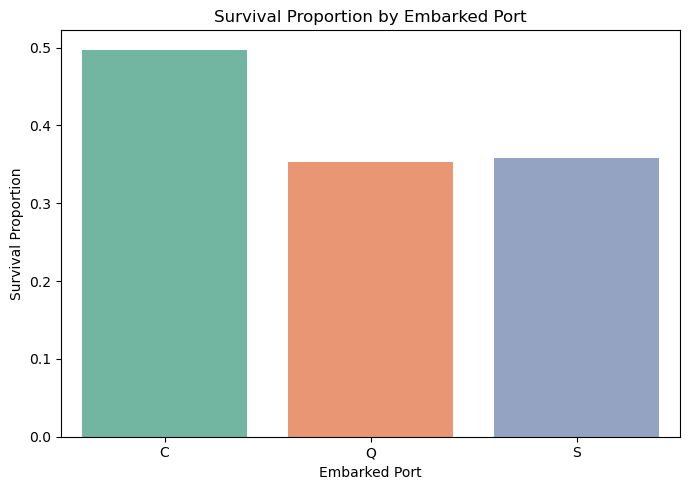

In [11]:
# 4b.1  survival proportion per embarked port (+ plot)
# 4b.1 survival proportion per embarked port (+ plot)

surv_port = t.groupby("Embarked")["Survived"].mean()

print("\n[1] Survival proportion by embarked port:")
print(surv_port.round(3).to_string())

plt.figure(figsize=(7, 5))

sns.barplot(
    x=surv_port.index,
    y=surv_port.values,
    palette="Set2"
)

plt.title("Survival Proportion by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Survival Proportion")

plt.tight_layout()
plt.show()

In [12]:
# 4b.2  youngest and oldest passengers
print("\n[2] Youngest age:", t["Age"].min(), "| Oldest age:", t["Age"].max())


[2] Youngest age: 0.4 | Oldest age: 66.6



[3] Passengers per age group:
Children    161
Adults      545
Seniors       7


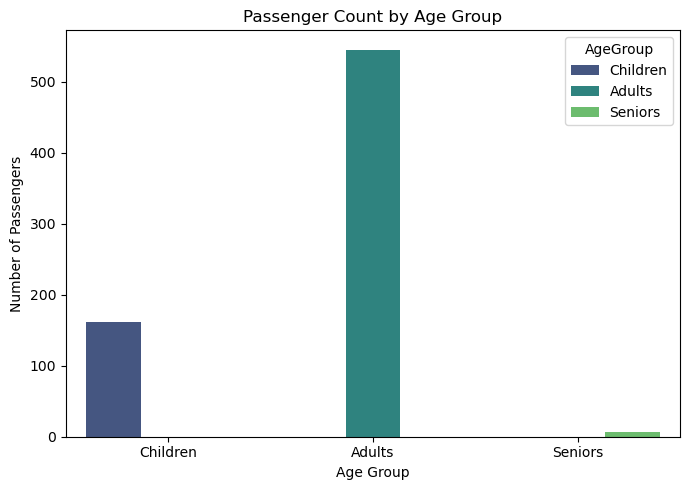

In [13]:
# 4b.3  count passengers in each age group (+ plot)
t["AgeGroup"] = pd.cut(
    t["Age"],
    bins=[0, 18, 60, 100],
    labels=["Children", "Adults", "Seniors"]
)

age_counts = t["AgeGroup"].value_counts().reindex(
    ["Children", "Adults", "Seniors"]
)

print("\n[3] Passengers per age group:")
print(age_counts.to_string())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=t,
    x="AgeGroup",
    order=["Children", "Adults", "Seniors"],
    hue="AgeGroup",
    palette="viridis"
)

plt.title("Passenger Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

In [14]:
# 4b.4  group by Embarked: count, average age, median fare
emb = t.groupby("Embarked").agg(
    passengers=("PassengerId", "count"),
    avg_age=("Age", "mean"),
    median_fare=("Fare", "median")
).round(2)
print("\n[4] By embarked port (count, avg age, median fare):")
print(emb.to_string())



[4] By embarked port (count, avg age, median fare):
          passengers  avg_age  median_fare
Embarked                                  
C                189    29.76        24.12
Q                 85    29.44        13.59
S                615    28.82        17.51


In [15]:
# 4b.5  family_size column via a function applied row-wise with lambda
def get_family_size(siblings, parents):
    return siblings + parents + 1            # +1 for the passenger themselves
t["family_size"] = t.apply(lambda row: get_family_size(row["SibSp"], row["Parch"]),
                           axis=1)
print("\n[5] family_size added. Sample:")
print(t[["SibSp", "Parch", "family_size"]].head(5).to_string(index=False))


[5] family_size added. Sample:
 SibSp  Parch  family_size
     0      0            1
     0      2            3
     0      0            1
     0      0            1
     0      0            1



[6] Survival rate by cabin type (deck):
CabinType
E          0.592
C          0.571
B          0.500
A          0.471
D          0.466
G          0.385
Unknown    0.347
F          0.300


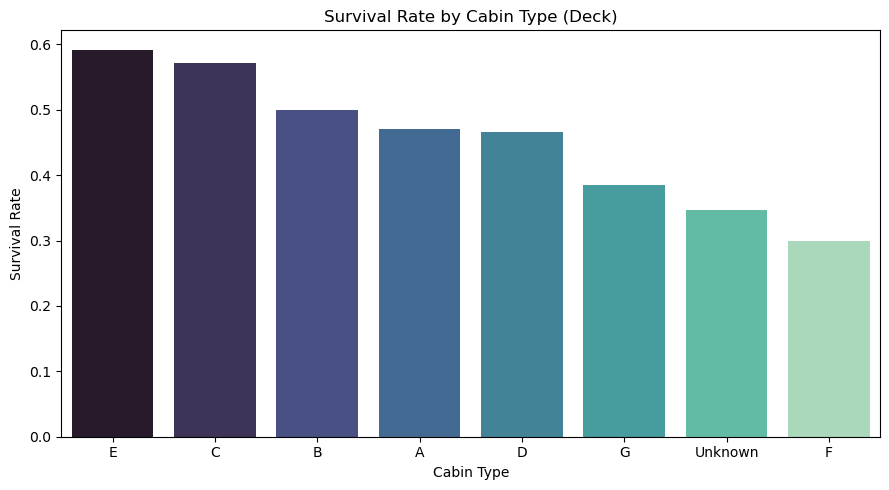


Done.


In [16]:
# 4b.6  cabin type (deck) vs survival (+ plot)
t["CabinType"] = t["Cabin"].astype(str).str[0]
t.loc[t["Cabin"].isna(), "CabinType"] = "Unknown"

cabin_surv = (
    t.groupby("CabinType")["Survived"]
    .mean()
    .sort_values(ascending=False)
)

print("\n[6] Survival rate by cabin type (deck):")
print(cabin_surv.round(3).to_string())

plt.figure(figsize=(9, 5))

sns.barplot(
    x=cabin_surv.index,
    y=cabin_surv.values,
    palette="mako"
)

plt.title("Survival Rate by Cabin Type (Deck)")
plt.xlabel("Cabin Type")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.show()

print("\nDone.")